In [177]:
"""
CST8507 Assignment 1: Comparative Analysis of Text Representation
Author: Peng Wang
Student Number: 041107730

Classify Amazon reviews into five categories (1-5) using different
textual features (n-gram, TF-IDF, Word2Vec) and ML classifiers
(Logistic Regression, Linear SVM). Includes hyperparameter tuning
and error analysis across feature representations.
"""

'\nCST8507 Assignment 1: Comparative Analysis of Text Representation\nAuthor: Peng Wang\nStudent Number: 041107730\n\nClassify Amazon reviews into five categories (1-5) using different\ntextual features (n-gram, TF-IDF, Word2Vec) and ML classifiers\n(Logistic Regression, Linear SVM). Includes hyperparameter tuning\nand error analysis across feature representations.\n'

In [178]:
# ============================================================
# 导入依赖库
# Import Dependencies
# ============================================================
import os
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 加载环境变量（学生信息）
# Load environment variables (student information)
from dotenv import load_dotenv

# 自然语言处理工具
# Natural language processing tools
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# 机器学习工具
# Machine learning tools
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

# 词嵌入模型
# Word embedding model
from gensim.models import Word2Vec

# 格式化输出表格
# Formatted table output
from tabulate import tabulate

In [179]:
# ============================================================
# 配置常量
# Configuration Constants
# ============================================================
# 随机种子，确保实验可复现
# Random seed to ensure reproducibility
RANDOM_STATE = 42

# 测试集比例（20%）
# Test set ratio (20%)
TEST_SIZE = 0.2

# 子集大小：如果数据集过大，随机抽取此数量的记录
# Subset size: randomly sample this many records if dataset is too large
SUBSET_SIZE = 50000

# n-gram 范围：使用 unigram + bigram
# n-gram range: use unigram + bigram
NGRAM_RANGE = (1, 2)

# 最大特征数量，限制 BoW 和 TF-IDF 的维度
# Maximum number of features, limit BoW and TF-IDF dimensions
MAX_FEATURES = 10000

# Word2Vec 向量维度
# Word2Vec vector dimension
W2V_VECTOR_SIZE = 100

# Word2Vec 上下文窗口大小
# 每个词左右最多看 5 个词作为上下文
# Word2Vec context window size
W2V_WINDOW = 5

# Word2Vec 最小词频：低于此频率的词将被忽略
# 出现次数 < 2 的词会被丢弃
# Word2Vec minimum word count: words below this frequency are ignored
W2V_MIN_COUNT = 2

# Word2Vec 训练工作线程数
# Word2Vec training worker threads
W2V_WORKERS = 4

# Logistic Regression 最大迭代次数
# Logistic Regression maximum iterations
LR_MAX_ITER = 1000

# 交叉验证折数
# Cross-validation fold count
CV_FOLDS = 5

# 输出图表目录
# Output chart directory
OUTPUT_DIR = "assignment1_images"

In [180]:
# ============================================================
# 步骤 0：实验初始化
# Step 0: Lab Initialization
# ============================================================
def initialize_lab():
    """实验初始化：加载环境变量、下载NLTK数据、设置显示选项
    Lab initialization: load env vars, download NLTK data, set display options"""

    # 加载学生信息
    # Load student information
    load_dotenv(".env.local")
    student_name = os.getenv("NAME", "Peng Wang")
    student_number = os.getenv("NUMBER", "041107730")

    # 忽略警告信息，保持输出清洁
    # Suppress warnings to keep output clean
    warnings.filterwarnings("ignore")

    # 下载 NLTK 所需数据包（静默模式）
    # Download required NLTK data packages (quiet mode)
    nltk.download("punkt", quiet=True)
    nltk.download("punkt_tab", quiet=True)
    nltk.download("stopwords", quiet=True)
    nltk.download("wordnet", quiet=True)

    # 设置 pandas 显示选项，确保完整输出
    # Set pandas display options to ensure full output
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", 1000)
    pd.set_option("display.expand_frame_repr", False)

    # 设置 matplotlib 风格
    # Set matplotlib style
    plt.style.use("seaborn-v0_8-whitegrid")

    # 创建图表输出目录
    # Create chart output directory
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    # 打印实验信息
    # Print lab information
    print("=" * 60)
    print("CST8507 Assignment 1: Text Representation Analysis")
    print(f"Student: {student_name} ({student_number})")
    print("=" * 60)

    return student_name, student_number

In [181]:
# ============================================================
# 步骤 1：数据加载
# Step 1: Data Loading
# ============================================================
def load_data(data_path="Reviews.csv"):
    """加载Amazon评论数据集
    Load Amazon reviews dataset"""

    print("\n" + "=" * 60)
    print("Step 1: Data Loading")
    print("=" * 60)

    # 读取 CSV 文件，仅加载需要的列
    # Read CSV file, only load required columns
    df = pd.read_csv(data_path, usecols=["Score", "Text"])

    # 显示原始数据集信息
    # Display original dataset info
    print(f"Original dataset size: {len(df)} records")
    print(f"Columns: {list(df.columns)}")

    # 删除缺失值
    # Drop missing values
    df = df.dropna(subset=["Score", "Text"])
    print(f"After dropping NaN: {len(df)} records")

    # 如果数据集过大，随机抽取子集
    # If dataset is too large, randomly sample a subset
    if len(df) > SUBSET_SIZE:
        df = df.sample(n=SUBSET_SIZE, random_state=RANDOM_STATE)
        print(f"Sampled subset: {SUBSET_SIZE} records")

    # 显示类别分布
    # Display class distribution
    print(f"\nScore distribution:")
    score_counts = df["Score"].value_counts().sort_index()
    for score, count in score_counts.items():
        print(f"  Score {score}: {count} ({count/len(df)*100:.1f}%)")

    # 显示数据样例
    # Display data samples
    print(f"\nSample data:")
    print(df.head())

    return df

In [182]:
# ============================================================
# 步骤 2：数据预处理
# Step 2: Data Preprocessing
# ============================================================
def preprocess_text(text):
    """对单条文本执行预处理流水线
    Execute preprocessing pipeline on a single text"""

    # 转换为小写
    # Convert to lowercase
    text = text.lower()

    # 移除 HTML 标签（评论中可能包含 <br/> 等）
    # Remove HTML tags (reviews may contain <br/> etc.)
    text = re.sub(r"<[^>]+>", " ", text)

    # 移除标点和特殊字符，仅保留字母和空格
    # Remove punctuation and special characters, keep only letters and spaces
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # 移除多余空格
    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    # 分词
    # Tokenization
    tokens = word_tokenize(text)

    # 移除停用词
    # Remove stop words
    stop_words = set(stopwords.words("english"))
    tokens = [t for t in tokens if t not in stop_words]

    # 词形还原（还原为词典形式，比词干提取更准确）
    # Lemmatization (reduce to dictionary form, more accurate than stemming)
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    # 移除过短的词（长度 < 2 的词通常无意义）
    # Remove very short tokens (words with length < 2 are usually meaningless)
    tokens = [t for t in tokens if len(t) >= 2]

    return tokens


def preprocess_dataset(df):
    """对整个数据集执行预处理
    Execute preprocessing on the entire dataset"""

    print("\n" + "=" * 60)
    print("Step 2: Data Preprocessing")
    print("=" * 60)

    print("Preprocessing steps:")
    print("  1. Lowercasing")
    print("  2. Remove HTML tags")
    print("  3. Remove punctuation and special characters")
    print("  4. Tokenization (NLTK word_tokenize)")
    print("  5. Stop words removal (English)")
    print("  6. Lemmatization (WordNetLemmatizer)")
    print("  7. Remove short tokens (length < 2)")

    # 对所有文本执行预处理，保存为 token 列表
    # Preprocess all texts, save as token lists
    print("\nProcessing texts...")
    df = df.copy()
    df["tokens"] = df["Text"].apply(preprocess_text)

    # 将 token 列表重新连接为字符串（供 CountVectorizer/TfidfVectorizer 使用）
    # Rejoin token lists to strings (for CountVectorizer/TfidfVectorizer)
    df["cleaned_text"] = df["tokens"].apply(lambda tokens: " ".join(tokens))

    # 显示预处理结果样例
    # Display preprocessing result samples
    print(f"\nPreprocessing complete. Sample results:")
    for i in range(3):
        original = df.iloc[i]["Text"][:80]
        cleaned = df.iloc[i]["cleaned_text"][:80]
        print(f"\n  Original : {original}...")
        print(f"  Cleaned  : {cleaned}...")

    # 统计预处理后平均 token 数
    # Calculate average token count after preprocessing
    avg_tokens = df["tokens"].apply(len).mean()
    print(f"\nAverage tokens per review after preprocessing: {avg_tokens:.1f}")

    return df

In [183]:
# ============================================================
# 步骤 3A：训练集/测试集划分
# Step 3A: Train/Test Split
# ============================================================
def split_data(df):
    """先划分再提取特征，避免数据泄露
    Split before feature extraction to prevent data leakage"""

    print("\n" + "=" * 60)
    print("Step 3: Train/Test Split")
    print("=" * 60)

    # 分离特征和标签
    # Separate features and labels
    X = df["cleaned_text"]
    X_tokens = df["tokens"]
    y = df["Score"]

    # 使用分层抽样划分数据集（保持各类别比例一致）
    # Use stratified sampling to split dataset (maintain class proportions)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
    )

    # 同步划分 token 列表（Word2Vec 需要 token 列表输入）
    # Synchronize split for token lists (Word2Vec requires token list input)
    X_train_tokens = X_tokens.loc[X_train.index]
    X_test_tokens = X_tokens.loc[X_test.index]

    print(f"Training set: {len(X_train)} samples")
    print(f"Test set:     {len(X_test)} samples")
    print(f"Split ratio:  {1 - TEST_SIZE:.0%} / {TEST_SIZE:.0%}")
    print(f"Stratified:   Yes (class proportions preserved)")

    # 显示训练集类别分布
    # Display training set class distribution
    print(f"\nTraining set class distribution:")
    train_counts = y_train.value_counts().sort_index()
    for score, count in train_counts.items():
        print(f"  Score {score}: {count} ({count/len(y_train)*100:.1f}%)")

    # 显示 token 列表样例（Word2Vec 输入格式）
    # Display token list samples (Word2Vec input format)
    print(f"\nToken list samples (for Word2Vec):")
    for i, (idx, tokens) in enumerate(X_train_tokens.head(3).items()):
        print(f"  [{i}] Index {idx}: {tokens[:8]}{'...' if len(tokens) > 8 else ''}")
        print(f"       Length: {len(tokens)} tokens")

    return X_train, X_test, y_train, y_test, X_train_tokens, X_test_tokens

In [184]:
# ============================================================
# 步骤 3B：特征提取 - n-gram (BoW)
# Step 3B: Feature Extraction - n-gram (BoW)
# ============================================================
def extract_ngram_features(X_train, X_test):
    """使用CountVectorizer提取n-gram (BoW)特征
    Extract n-gram (BoW) features using CountVectorizer"""

    print("\n" + "=" * 60)
    print("Step 3B: Feature Extraction - n-gram (BoW)")
    print("=" * 60)

    # 创建 CountVectorizer：unigram + bigram，限制最大特征数
    # Create CountVectorizer: unigram + bigram, limit max features
    # 参数：ngram_range=(1,2) 表示同时使用单个词和两个连续词作为特征，
    #       max_features=10000 限制词汇表大小以降低维度和内存使用
    # Parameters: ngram_range=(1,2) uses both single words and consecutive word pairs as features,
    #       max_features=10000 limits vocabulary size to reduce dimensionality and memory usage
    bow_vectorizer = CountVectorizer(
        ngram_range=NGRAM_RANGE, max_features=MAX_FEATURES
    )

    # 在训练集上拟合并转换，在测试集上仅转换（防止数据泄露）
    # Fit and transform on training set, only transform on test set (prevent data leakage)
    X_train_bow = bow_vectorizer.fit_transform(X_train)
    X_test_bow = bow_vectorizer.transform(X_test)

    print(f"n-gram range: {NGRAM_RANGE}")
    print(f"Max features: {MAX_FEATURES}")
    print(f"Training feature matrix shape: {X_train_bow.shape}")
    print(f"Test feature matrix shape:     {X_test_bow.shape}")
    print(f"Vocabulary size: {len(bow_vectorizer.vocabulary_)}")

    return X_train_bow, X_test_bow, bow_vectorizer

In [185]:
# ============================================================
# 步骤 3C：特征提取 - TF-IDF
# Step 3C: Feature Extraction - TF-IDF
# ============================================================
def extract_tfidf_features(X_train, X_test):
    """使用TfidfVectorizer提取TF-IDF特征
    Extract TF-IDF features using TfidfVectorizer"""

    print("\n" + "=" * 60)
    print("Step 3C: Feature Extraction - TF-IDF")
    print("=" * 60)

    # 创建 TfidfVectorizer：TF-IDF 在 BoW 基础上增加逆文档频率权重，
    #   降低常见词的权重，提升稀有但有区分度的词的权重
    # Create TfidfVectorizer: TF-IDF adds inverse document frequency weighting on top of BoW,
    #   reduces weight of common words, increases weight of rare but discriminative words
    tfidf_vectorizer = TfidfVectorizer(
        ngram_range=NGRAM_RANGE, max_features=MAX_FEATURES
    )

    # 在训练集上拟合并转换，在测试集上仅转换
    # Fit and transform on training set, only transform on test set
    X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
    X_test_tfidf = tfidf_vectorizer.transform(X_test)

    print(f"n-gram range: {NGRAM_RANGE}")
    print(f"Max features: {MAX_FEATURES}")
    print(f"Training feature matrix shape: {X_train_tfidf.shape}")
    print(f"Test feature matrix shape:     {X_test_tfidf.shape}")

    return X_train_tfidf, X_test_tfidf, tfidf_vectorizer

In [186]:
# ============================================================
# 步骤 3D：特征提取 - Word2Vec
# Step 3D: Feature Extraction - Word2Vec
# ============================================================
def get_document_vector(tokens, model, vector_size):
    """计算一个文档的 Word2Vec 平均向量
    Compute the average Word2Vec vector for a document"""

    # 过滤出模型词汇表中存在的词的向量
    # Filter word vectors that exist in the model vocabulary
    vectors = [model.wv[word] for word in tokens if word in model.wv]

    # 如果没有有效词向量，返回全零向量
    # If no valid word vectors, return zero vector
    if len(vectors) == 0:
        return np.zeros(vector_size)

    # 取所有词向量的平均值作为文档向量
    # Average all word vectors as the document vector
    return np.mean(vectors, axis=0)


def extract_word2vec_features(X_train_tokens, X_test_tokens):
    """训练Word2Vec模型并提取文档向量
    Train Word2Vec model and extract document vectors"""

    print("\n" + "=" * 60)
    print("Step 3D: Feature Extraction - Word2Vec")
    print("=" * 60)

    # 在训练集上训练 Word2Vec 模型
    # Train Word2Vec model on training set
    # 参数：vector_size=100 每个词用100维向量表示，
    #       window=5 上下文窗口为前后各5个词，
    #       min_count=2 忽略出现次数少于2次的词（减少噪声），
    #       workers=4 使用4个线程并行训练
    # Parameters: vector_size=100 represents each word with a 100-dim vector,
    #       window=5 context window covers 5 words before and after,
    #       min_count=2 ignores words appearing less than 2 times (reduce noise),
    #       workers=4 uses 4 threads for parallel training
    print("Training Word2Vec model on training data...")
    w2v_model = Word2Vec(
        sentences=X_train_tokens.tolist(),
        vector_size=W2V_VECTOR_SIZE,
        window=W2V_WINDOW,
        min_count=W2V_MIN_COUNT,
        workers=W2V_WORKERS,
        seed=RANDOM_STATE,
    )

    print(f"Word2Vec parameters:")
    print(f"  vector_size: {W2V_VECTOR_SIZE}")
    print(f"  window:      {W2V_WINDOW}")
    print(f"  min_count:   {W2V_MIN_COUNT}")
    print(f"  Vocabulary size: {len(w2v_model.wv)}")

    # 将每个文档转换为平均词向量
    # Convert each document to average word vector
    print("Computing document vectors...")
    X_train_w2v = np.array(
        [
            get_document_vector(tokens, w2v_model, W2V_VECTOR_SIZE)
            for tokens in X_train_tokens
        ]
    )
    X_test_w2v = np.array(
        [
            get_document_vector(tokens, w2v_model, W2V_VECTOR_SIZE)
            for tokens in X_test_tokens
        ]
    )

    print(f"Training feature matrix shape: {X_train_w2v.shape}")
    print(f"Test feature matrix shape:     {X_test_w2v.shape}")

    return X_train_w2v, X_test_w2v, w2v_model

In [187]:
# ============================================================
# 步骤 4：模型训练与评估
# Step 4: Model Training and Evaluation
# ============================================================
def train_and_evaluate(X_train, X_test, y_train, y_test, model, model_name, feature_name):
    """训练单个模型并评估，返回结果字典
    Train a single model and evaluate, return results dict"""

    # 训练模型
    # Train model
    model.fit(X_train, y_train)

    # 在测试集上预测
    # Predict on test set
    y_pred = model.predict(X_test)

    # 计算评估指标
    # Calculate evaluation metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n  {model_name} + {feature_name}:")
    print(f"    Accuracy: {acc:.4f}")
    print(f"    F1-score (weighted): {f1:.4f}")

    return {
        "feature": feature_name,
        "model_name": model_name,
        "model": model,
        "accuracy": acc,
        "f1_score": f1,
        "confusion_matrix": cm,
        "y_pred": y_pred,
        "y_test": y_test,
    }


def run_all_models(features_dict, y_train, y_test):
    """在所有特征和模型组合上训练并评估
    Train and evaluate on all feature and model combinations"""

    print("\n" + "=" * 60)
    print("Step 4: Model Training and Evaluation")
    print("=" * 60)

    # 定义两个分类器
    # Define two classifiers
    # Logistic Regression：多分类使用 multinomial 策略，lbfgs 求解器适合中等规模数据
    # Logistic Regression: multinomial strategy for multiclass, lbfgs solver for medium-scale data
    # LinearSVC：线性 SVM，dual="auto" 让算法自动选择求解策略
    # LinearSVC: linear SVM, dual="auto" lets the algorithm auto-select solving strategy
    classifiers = {
        "Logistic Regression": LogisticRegression(
            max_iter=LR_MAX_ITER, random_state=RANDOM_STATE
        ),
        "Linear SVM": LinearSVC(
            max_iter=LR_MAX_ITER, dual="auto", random_state=RANDOM_STATE
        ),
    }

    all_results = []

    # 遍历所有特征 × 模型组合
    # Iterate through all feature × model combinations
    for feature_name, (X_train_feat, X_test_feat) in features_dict.items():
        for model_name, model in classifiers.items():
            # 为每个组合创建新的模型实例（避免状态泄露）
            # Create a new model instance for each combination (avoid state leakage)
            from sklearn.base import clone

            model_clone = clone(model)
            result = train_and_evaluate(
                X_train_feat, X_test_feat, y_train, y_test,
                model_clone, model_name, feature_name
            )
            all_results.append(result)

    return all_results

In [188]:
# ============================================================
# 步骤 5：结果可视化 - 混淆矩阵
# Step 5: Results Visualization - Confusion Matrix
# ============================================================
def plot_confusion_matrices(all_results):
    """为所有模型绘制混淆矩阵
    Plot confusion matrices for all models"""

    print("\n" + "=" * 60)
    print("Step 5: Confusion Matrices")
    print("=" * 60)

    # 创建 2 行 3 列的子图布局（2 个模型 × 3 种特征）
    # Create 2x3 subplot layout (2 models × 3 features)
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle("Confusion Matrices for All Model-Feature Combinations", fontsize=14)

    for idx, result in enumerate(all_results):
        row = idx // 3
        col = idx % 3
        ax = axes[row, col]

        # 绘制混淆矩阵热力图
        # Plot confusion matrix heatmap
        disp = ConfusionMatrixDisplay(
            confusion_matrix=result["confusion_matrix"],
            display_labels=[1, 2, 3, 4, 5]
        )
        disp.plot(ax=ax, cmap="Blues", values_format="d")
        ax.set_title(f"{result['model_name']}\n{result['feature']}")

    plt.tight_layout()
    plt.savefig(
        os.path.join(OUTPUT_DIR, "confusion_matrices.png"),
        dpi=150, bbox_inches="tight"
    )
    plt.show()
    print(f"Saved: {OUTPUT_DIR}/confusion_matrices.png")

In [189]:
# ============================================================
# 步骤 6：结果汇总表
# Step 6: Results Summary Table
# ============================================================
def print_results_summary(all_results):
    """打印所有模型的结果汇总表
    Print results summary table for all models"""

    print("\n" + "=" * 60)
    print("Step 6: Results Summary")
    print("=" * 60)

    # 构建结果表格
    # Build results table
    table_data = []
    for r in all_results:
        table_data.append([
            r["feature"],
            r["model_name"],
            f"{r['accuracy']:.4f}",
            f"{r['f1_score']:.4f}",
        ])

    headers = ["Feature Type", "Model", "Accuracy", "F1-score"]
    print(tabulate(table_data, headers=headers, tablefmt="grid"))

    # 找出最佳模型
    # Find the best model
    best = max(all_results, key=lambda x: x["accuracy"])
    print(f"\nBest model: {best['model_name']} + {best['feature']}")
    print(f"  Accuracy: {best['accuracy']:.4f}")
    print(f"  F1-score: {best['f1_score']:.4f}")

    return best

In [190]:
# ============================================================
# 步骤 7：超参数调优
# Step 7: Hyperparameter Tuning
# ============================================================
def tune_hyperparameters(X_train_tfidf, y_train, X_test_tfidf, y_test):
    """对最佳特征组合进行超参数调优
    Perform hyperparameter tuning on the best feature combination"""

    print("\n" + "=" * 60)
    print("Step 7: Hyperparameter Tuning")
    print("=" * 60)

    # 对 Logistic Regression 进行网格搜索
    # Grid search for Logistic Regression
    # 参数空间：
    #   C - 正则化强度的倒数（越大正则化越弱，可能过拟合；越小正则化越强，可能欠拟合）
    #   solver - 优化算法（求解器），决定如何找到 loss function 的最小值：
    #     lbfgs: Limited-memory BFGS，拟牛顿法，利用二阶梯度近似加速收敛，
    #            适合中小规模数据，内存开销适中，支持 multinomial 多分类
    #     saga:  Stochastic Average Gradient Accelerated，随机平均梯度加速法，
    #            每次迭代只用部分样本更新梯度，适合大规模数据集，
    #            支持 L1/L2/Elastic-Net 正则化
    # Parameter space:
    #   C - inverse of regularization strength (larger = less regularization, may overfit;
    #       smaller = more regularization, may underfit)
    #   solver - optimization algorithm, determines how to minimize the loss function:
    #     lbfgs: quasi-Newton method using second-order gradient approximation,
    #            good for medium-scale data, supports multinomial multiclass
    #     saga:  stochastic gradient variant, updates with partial samples per iteration,
    #            efficient for large datasets, supports L1/L2/Elastic-Net regularization
    print("\n--- Logistic Regression Tuning ---")
    lr_param_grid = {
        "C": [0.01, 0.1, 1.0, 10.0],
        "solver": ["lbfgs", "saga"],
    }

    # GridSearchCV：网格搜索交叉验证，穷举所有参数组合，找到最优超参数
    # GridSearchCV: grid search with cross-validation, exhaustively tries all parameter
    #   combinations to find the optimal hyperparameters
    # 参数：
    #   estimator - 基础模型实例（LogisticRegression），
    #               max_iter=1000 设置最大迭代次数防止不收敛，
    #               random_state=42 确保可复现
    #   param_grid - 超参数搜索空间，所有组合会被逐一尝试
    #               （本例：4个C × 2个solver = 8种组合）
    #   cv - 交叉验证折数，将训练集分为 5 份，每次用 4 份训练、1 份验证，
    #        重复 5 次取平均，减少结果的随机性
    #   scoring - 评估指标，"accuracy" 表示以准确率选择最优参数
    #   n_jobs=-1 - 使用所有 CPU 核心并行计算，加速搜索过程
    #   verbose=0 - 不输出搜索过程的详细日志
    # Parameters:
    #   estimator - base model instance (LogisticRegression),
    #               max_iter=1000 prevents non-convergence,
    #               random_state=42 ensures reproducibility
    #   param_grid - hyperparameter search space, all combinations are tried
    #               (here: 4 C values × 2 solvers = 8 combinations)
    #   cv - cross-validation folds, splits training set into 5 parts,
    #        trains on 4 and validates on 1, repeats 5 times and averages
    #   scoring - evaluation metric, "accuracy" selects params by accuracy
    #   n_jobs=-1 - use all CPU cores for parallel computation
    #   verbose=0 - suppress detailed search logs
    lr_grid = GridSearchCV(
        LogisticRegression(max_iter=LR_MAX_ITER, random_state=RANDOM_STATE),
        lr_param_grid,
        cv=CV_FOLDS,
        scoring="accuracy",
        n_jobs=-1,
        verbose=0,
    )

    # 在训练集上执行网格搜索（自动完成交叉验证）
    # Execute grid search on training set (cross-validation is done automatically)
    lr_grid.fit(X_train_tfidf, y_train)

    # 打印所有参数组合的交叉验证结果
    # Print CV results for all parameter combinations
    print(f"\nAll parameter combinations ({len(lr_grid.cv_results_['params'])} total):")
    lr_cv_table = []
    for i, params in enumerate(lr_grid.cv_results_["params"]):
        mean_score = lr_grid.cv_results_["mean_test_score"][i]
        std_score = lr_grid.cv_results_["std_test_score"][i]
        rank = lr_grid.cv_results_["rank_test_score"][i]
        best_marker = " *" if rank == 1 else ""
        lr_cv_table.append([
            params.get("C", "-"),
            params.get("solver", "-"),
            f"{mean_score:.4f} ± {std_score:.4f}",
            rank,
            best_marker,
        ])
    print(tabulate(lr_cv_table, headers=["C", "Solver", "CV Accuracy (mean ± std)", "Rank", ""], tablefmt="grid"))

    # best_params_ 返回交叉验证中表现最好的参数组合
    # best_params_ returns the parameter combination with best CV performance
    print(f"\nBest parameters: {lr_grid.best_params_}")
    # best_score_ 返回最优参数对应的交叉验证平均准确率
    # best_score_ returns the mean CV accuracy of the best parameters
    print(f"Best CV accuracy: {lr_grid.best_score_:.4f}")

    # 用最佳参数在测试集上评估（best_estimator_ 是用最优参数重新训练的模型）
    # Evaluate with best params on test set (best_estimator_ is the model retrained with optimal params)
    lr_best_pred = lr_grid.best_estimator_.predict(X_test_tfidf)
    lr_best_acc = accuracy_score(y_test, lr_best_pred)
    lr_best_f1 = f1_score(y_test, lr_best_pred, average="weighted")
    print(f"Test accuracy (tuned): {lr_best_acc:.4f}")
    print(f"Test F1-score (tuned): {lr_best_f1:.4f}")

    # 对 Linear SVM 进行网格搜索
    # Grid search for Linear SVM
    # LinearSVC 的主要调优参数只有 C（正则化强度），
    # 因为 LinearSVC 不像 LogisticRegression 有 solver 选项
    # LinearSVC's main tuning parameter is only C (regularization strength),
    # since LinearSVC doesn't have a solver option like LogisticRegression
    print("\n--- Linear SVM Tuning ---")
    svm_param_grid = {
        "C": [0.01, 0.1, 1.0, 10.0],
    }

    # 同样使用 GridSearchCV 对 LinearSVC 进行超参数搜索
    # dual="auto" 让算法根据样本数和特征数自动选择对偶或原始形式求解
    # Similarly use GridSearchCV for LinearSVC hyperparameter search
    # dual="auto" lets the algorithm auto-select dual or primal formulation
    #   based on the number of samples vs features
    svm_grid = GridSearchCV(
        LinearSVC(max_iter=LR_MAX_ITER, dual="auto", random_state=RANDOM_STATE),
        svm_param_grid,
        cv=CV_FOLDS,
        scoring="accuracy",
        n_jobs=-1,
        verbose=0,
    )
    svm_grid.fit(X_train_tfidf, y_train)

    # 打印所有参数组合的交叉验证结果
    # Print CV results for all parameter combinations
    print(f"\nAll parameter combinations ({len(svm_grid.cv_results_['params'])} total):")
    svm_cv_table = []
    for i, params in enumerate(svm_grid.cv_results_["params"]):
        mean_score = svm_grid.cv_results_["mean_test_score"][i]
        std_score = svm_grid.cv_results_["std_test_score"][i]
        rank = svm_grid.cv_results_["rank_test_score"][i]
        best_marker = " *" if rank == 1 else ""
        svm_cv_table.append([
            params.get("C", "-"),
            f"{mean_score:.4f} ± {std_score:.4f}",
            rank,
            best_marker,
        ])
    print(tabulate(svm_cv_table, headers=["C", "CV Accuracy (mean ± std)", "Rank", ""], tablefmt="grid"))

    print(f"\nBest parameters: {svm_grid.best_params_}")
    print(f"Best CV accuracy: {svm_grid.best_score_:.4f}")

    # 用最佳参数在测试集上评估
    # Evaluate with best parameters on test set
    svm_best_pred = svm_grid.best_estimator_.predict(X_test_tfidf)
    svm_best_acc = accuracy_score(y_test, svm_best_pred)
    svm_best_f1 = f1_score(y_test, svm_best_pred, average="weighted")
    print(f"Test accuracy (tuned): {svm_best_acc:.4f}")
    print(f"Test F1-score (tuned): {svm_best_f1:.4f}")

    # 汇总调优结果
    # Summarize tuning results
    print("\n--- Tuning Summary ---")
    tuning_table = [
        ["Logistic Regression", str(lr_grid.best_params_), f"{lr_best_acc:.4f}", f"{lr_best_f1:.4f}"],
        ["Linear SVM", str(svm_grid.best_params_), f"{svm_best_acc:.4f}", f"{svm_best_f1:.4f}"],
    ]
    print(tabulate(tuning_table, headers=["Model", "Best Params", "Accuracy", "F1-score"], tablefmt="grid"))

    return lr_grid, svm_grid

In [193]:
# ============================================================
# 步骤 8：错误分析 (Part 2)
# Step 8: Error Analysis (Part 2)
# ============================================================

# ---- 情感词典（匹配预处理后的 lemmatized tokens）----
# ---- Sentiment lexicon (matches preprocessed lemmatized tokens) ----
_POS_WORDS = {
    "love", "loved", "great", "best", "excellent", "wonderful",
    "delicious", "perfect", "amazing", "fantastic", "awesome", "outstanding",
    "incredible", "superb", "brilliant", "exceptional", "terrific", "magnificent",
    "good", "nice", "enjoy", "enjoyed", "happy", "pleased",
    "satisfied", "recommend", "recommended", "favorite", "favourite",
    "beautiful", "superior", "lovely", "tasty", "yummy", "refreshing",
    "smooth", "fresh", "healthy", "delightful", "exciting", "excited",
    "hooked", "impressed", "addicted", "heavenly", "divine", "splendid",
}
_NEG_WORDS = {
    "bad", "terrible", "worst", "horrible", "hate", "hated", "disappointing",
    "disappointed", "awful", "dreadful", "disgusting", "nasty", "inedible",
    "ruined", "useless", "gross", "poor", "broken", "waste", "wasted",
    "tasteless", "bland", "boring", "mediocre", "stale", "overpriced",
    "weak", "dry", "bitter", "unpleasant", "rancid", "spoiled", "damaged",
    "flavorless", "flavourless", "lacking", "leaked", "leaking", "horrendous",
    "cheap", "soggy", "mushy", "sour", "flat", "watery", "inferior",
}
# ---- 转折/否定词（预处理中被移除为 stop words，用于检测丢失信号）----
# ---- Contrast/negation words (removed as stop words, for detecting lost signals) ----
_CONTRAST_WORDS = {
    "but", "however", "although", "though", "yet", "still", "despite",
    "except", "unfortunately", "nonetheless", "nevertheless", "whereas",
}
_NEGATION_WORDS = {
    "not", "no", "never", "don't", "doesn't", "didn't", "wasn't", "isn't",
    "aren't", "can't", "couldn't", "won't", "wouldn't", "shouldn't", "hardly",
}


def _clean_html(text):
    """清理 HTML 标签和多余空格 / Clean HTML tags and extra whitespace"""
    clean = re.sub(r"<[^>]+>", " ", text)
    return re.sub(r"\s+", " ", clean).strip()


def _extract_token_context(tokens, keyword, window=4):
    """从 token 列表中提取关键词周围的上下文片段
    Extract context snippet around a keyword from token list"""
    for i, t in enumerate(tokens):
        if t == keyword:
            start = max(0, i - window)
            end = min(len(tokens), i + window + 1)
            prefix = "..." if start > 0 else ""
            suffix = "..." if end < len(tokens) else ""
            return f'{prefix}{" ".join(tokens[start:end])}{suffix}'
    return f"...{keyword}..."


def _extract_raw_snippet(text, keyword, window=6):
    """从原文中提取关键词前后的上下文片段（用于展示丢失信号）
    Extract context snippet from raw text around keyword (for lost signal display)"""
    words = text.split()
    kw = keyword.lower().strip(".,!?;:\"'()[]")
    for i, w in enumerate(words):
        if w.lower().strip(".,!?;:\"'()[]") == kw:
            s = max(0, i - window)
            e = min(len(words), i + window + 1)
            pre = "..." if s > 0 else ""
            suf = "..." if e < len(words) else ""
            return f'{pre}{" ".join(words[s:e])}{suf}'
    return f"...{keyword}..."


def _analyze_error(raw_text, tokens, true_label, pred_label):
    """基于预处理后的 tokens（模型实际输入）分析错误原因
    Analyze error causes based on preprocessed tokens (model's actual input).

    分析策略 / Analysis strategy:
    Phase 1 — 分析模型看到的 tokens（情感词检测）
    Phase 2 — 分析预处理中丢失的信号（转折/否定词）
    Phase 3 — 预测方向结论
    Phase 4 — 类别边界分析
    """
    evidence_rows = []
    pred_higher = pred_label > true_label
    token_set = set(tokens)
    n_tokens = len(tokens)

    # ========== Phase 1: 分析模型看到的 tokens ==========
    # 在预处理后的 token 列表中查找正/负面情感词
    # Find positive/negative sentiment words in preprocessed token list

    tok_pos = [t for t in dict.fromkeys(tokens) if t in _POS_WORDS]
    tok_neg = [t for t in dict.fromkeys(tokens) if t in _NEG_WORDS]

    if tok_pos:
        snippet = _extract_token_context(tokens, tok_pos[0], window=3)
        pos_str = ", ".join(f'"{w}"' for w in tok_pos[:5])
        evidence_rows.append([
            f'Tokens: {pos_str}  ← "{snippet}"',
            f"{len(tok_pos)} positive word(s) in model input → pushes prediction higher",
            f"模型输入含 {len(tok_pos)} 个正面词 → 推高预测",
        ])

    if tok_neg:
        snippet = _extract_token_context(tokens, tok_neg[0], window=3)
        neg_str = ", ".join(f'"{w}"' for w in tok_neg[:5])
        evidence_rows.append([
            f'Tokens: {neg_str}  ← "{snippet}"',
            f"{len(tok_neg)} negative word(s) in model input → pushes prediction lower",
            f"模型输入含 {len(tok_neg)} 个负面词 → 拉低预测",
        ])

    # ========== Phase 2: 分析预处理中丢失的信号 ==========
    # 检测原文中被 stop words 过滤移除的转折/否定词
    # Detect contrast/negation words removed by stop word filtering

    clean_raw = _clean_html(raw_text).lower()
    raw_words = [w.strip(".,!?;:\"'()[]") for w in clean_raw.split()]

    # 2a. 丢失的转折词 / Lost contrast words
    lost_contrast = [w for w in raw_words if w in _CONTRAST_WORDS and w not in token_set]
    if lost_contrast:
        lost_unique = list(dict.fromkeys(lost_contrast))[:3]
        lost_str = ", ".join(f'"{w}"' for w in lost_unique)
        first_cw = lost_unique[0]
        snippet = _extract_raw_snippet(clean_raw, first_cw, window=5)
        evidence_rows.append([
            f'Lost: {lost_str}  ← raw: "{snippet}"',
            f"Contrast word(s) removed as stop words → model lost sentiment transition signal",
            f"转折词被 stop words 过滤移除 → 模型丢失情感转换信号",
        ])

    # 2b. 丢失的否定结构 / Lost negation structures
    #     检查原文中 "not good", "don't recommend" 等结构
    lost_negation_pairs = []
    for i, w in enumerate(raw_words):
        is_neg = w in _NEGATION_WORDS or w.endswith("n't")
        if is_neg and w not in token_set:
            for j in range(i + 1, min(i + 4, len(raw_words))):
                rw = raw_words[j]
                if rw in _POS_WORDS or rw in _NEG_WORDS:
                    lost_negation_pairs.append((w, rw))
                    break
    if lost_negation_pairs:
        neg_w, sent_w = lost_negation_pairs[0]
        evidence_rows.append([
            f'Lost: "{neg_w} {sent_w}" → only "{sent_w}" survives',
            f'Negation "{neg_w}" removed → "{sent_w}" kept without negator, meaning reversed',
            f'否定词 "{neg_w}" 被移除 → 仅保留 "{sent_w}"，语义被反转',
        ])

    # ========== Phase 3: 预测方向结论 ==========
    delta = abs(true_label - pred_label)
    direction = "over" if pred_higher else "under"
    dir_cn = "高估" if pred_higher else "低估"

    if tok_pos and tok_neg:
        dominant = "positive" if pred_higher else "negative"
        dom_cn = "正面" if pred_higher else "负面"
        evidence_rows.append([
            f"→ Model saw: {len(tok_pos)} pos vs {len(tok_neg)} neg tokens",
            f"Mixed sentiment in tokens: model {direction}-estimated "
            f"(pred {pred_label} vs true {true_label}), '{dominant}' words dominated",
            f"tokens 中正负混合：模型{dir_cn}（预测{pred_label} vs 真实{true_label}），"
            f"'{dom_cn}'词主导了决策",
        ])
    elif tok_pos and not tok_neg:
        if lost_contrast or lost_negation_pairs:
            evidence_rows.append([
                f"→ Model saw: {len(tok_pos)} pos, 0 neg (signals lost)",
                f"Model {direction}-estimated: only positive tokens survived preprocessing, "
                f"negative/contrast signals were removed as stop words",
                f"模型{dir_cn}：预处理后仅剩正面词，"
                f"负面/转折信号已被 stop words 移除",
            ])
        elif pred_higher:
            evidence_rows.append([
                f"→ Model saw: {len(tok_pos)} pos, 0 neg",
                f"Model {direction}-estimated: positive words dominated, "
                f"implicit dissatisfaction not captured by keyword-based features",
                f"模型{dir_cn}：正面词主导，隐含的不满未被基于关键词的特征捕获",
            ])
        else:
            evidence_rows.append([
                f"→ Model saw: {len(tok_pos)} pos, 0 neg",
                f"Model {direction}-estimated: positive words present but "
                f"not strong enough for score {true_label}",
                f"模型{dir_cn}：有正面词但不足以支撑分数 {true_label}",
            ])
    elif tok_neg and not tok_pos:
        if pred_higher:
            evidence_rows.append([
                f"→ Model saw: 0 pos, {len(tok_neg)} neg",
                f"Model {direction}-estimated: negative words present but "
                f"model focused on other textual signals",
                f"模型{dir_cn}：有负面词但模型关注了其他文本信号",
            ])
        else:
            evidence_rows.append([
                f"→ Model saw: 0 pos, {len(tok_neg)} neg",
                f"Model {direction}-estimated: negative words dominated, "
                f"true score {true_label} reflects user's partial satisfaction",
                f"模型{dir_cn}：负面词主导，真实分数 {true_label} 反映用户的部分满意",
            ])
    else:
        # 模型输入中无情感关键词 / No sentiment keywords in model input
        if n_tokens < 8:
            evidence_rows.append([
                f"→ {n_tokens} tokens, 0 sentiment keywords",
                f"Very short after preprocessing: sparse features, model {direction}-estimated",
                f"预处理后极短（{n_tokens} tokens），特征稀疏，模型{dir_cn}",
            ])
        elif n_tokens > 40:
            evidence_rows.append([
                f"→ {n_tokens} tokens, 0 sentiment keywords",
                f"Long text but no explicit sentiment words: opinion expressed through "
                f"narrative/context, model {direction}-estimated to {pred_label}",
                f"长文本但无显式情感词：观点通过叙事/语境表达，模型{dir_cn}为 {pred_label}",
            ])
        else:
            evidence_rows.append([
                f"→ {n_tokens} tokens, 0 sentiment keywords",
                f"No sentiment keywords in model input: opinion via tone/context, "
                f"model {direction}-estimated (pred {pred_label} vs true {true_label})",
                f"模型输入无情感关键词：观点通过语气/语境表达，"
                f"模型{dir_cn}（预测{pred_label} vs 真实{true_label}）",
            ])

    # ========== Phase 4: 类别边界 ==========
    if delta >= 3:
        evidence_rows.append([
            f"True={true_label} → Pred={pred_label} (Δ={delta})",
            "Extreme misprediction: model completely misread sentiment",
            f"极端误判（差{delta}级）：模型完全误读情感倾向",
        ])
    elif delta == 1 and true_label in [2, 3, 4]:
        evidence_rows.append([
            f"True={true_label} → Pred={pred_label} (Δ=1)",
            "Adjacent scores: very subtle sentiment boundary",
            f"相邻类别（{true_label}↔{pred_label}）：情感差异极微",
        ])

    return evidence_rows


def _analyze_cross_rep_error(raw_text, tokens, true_label, category_type,
                             ngram_pred, tfidf_pred, w2v_pred):
    """针对跨表示分析，在基础分析上追加表示方法差异化解释
    Add representation-specific analysis on top of base error analysis"""

    main_pred = tfidf_pred if tfidf_pred != "-" else ngram_pred
    evidence_rows = _analyze_error(raw_text, tokens, true_label,
                                   main_pred if main_pred != "-" else true_label)
    n_tokens = len(tokens)

    if category_type == "all_fail":
        evidence_rows.append([
            f"All wrong: BoW→{ngram_pred}, TF-IDF→{tfidf_pred}, W2V→{w2v_pred}",
            "All 3 representations failed → text is inherently ambiguous, "
            "not a representation method problem",
            "三种表示全部失败 → 文本本身歧义/含糊，非表示方法问题",
        ])

    elif category_type == "bow_tfidf_only":
        evidence_rows.append([
            f"BoW→{ngram_pred} ✗, TF-IDF→{tfidf_pred} ✗ | W2V→{w2v_pred} ✓",
            "BoW/TF-IDF treat words independently (bag-of-words), "
            "miss context & word relationships that W2V captures",
            "BoW/TF-IDF 独立处理词（词袋模型），"
            "丢失了 W2V 能捕获的上下文和词间关系",
        ])

    elif category_type == "w2v_only":
        evidence_rows.append([
            f"W2V→{w2v_pred} ✗ | BoW→{ngram_pred} ✓, TF-IDF→{tfidf_pred} ✓",
            "W2V averages ALL word vectors into one → key sentiment words "
            "diluted by neutral/irrelevant words",
            "W2V 将所有词向量平均为一个 → 关键情感词被大量中性/无关词稀释",
        ])
        tok_sentiment = [t for t in tokens if t in _POS_WORDS or t in _NEG_WORDS]
        if tok_sentiment and n_tokens > 10:
            ratio = len(tok_sentiment) / n_tokens * 100
            kw_str = ", ".join(f'"{w}"' for w in list(dict.fromkeys(tok_sentiment))[:5])
            evidence_rows.append([
                f"Sentiment tokens: {kw_str} = {len(tok_sentiment)}/{n_tokens} ({ratio:.0f}%)",
                f"Only {ratio:.0f}% tokens carry sentiment → "
                f"BoW/TF-IDF weight these directly, W2V dilutes in {n_tokens}-dim average",
                f"仅 {ratio:.0f}% tokens 携带情感 → "
                f"BoW/TF-IDF 直接加权，W2V 在 {n_tokens} 个词的平均中稀释",
            ])

    return evidence_rows


def _wrap_text(text, width=100):
    """将长文本按指定宽度换行显示
    Wrap long text at specified width for display"""
    import textwrap
    clean = _clean_html(text)
    lines = textwrap.wrap(clean, width=width)
    return "\n       ".join(lines)


def _print_error_sample(sample_num, idx, raw_text, tokens, true_label, pred_label):
    """打印单个误分类样本（含原文、预处理 tokens 和原因表格）
    Print a single misclassified sample with raw text, preprocessed tokens, and cause table"""
    print(f"\n  [{sample_num}] Index: {idx}  |  True: {true_label}  →  Predicted: {pred_label}")
    print(f"  Raw:     {_wrap_text(raw_text)}")
    tok_display = tokens[:20]
    suffix = f"... ({len(tokens)} total)" if len(tokens) > 20 else ""
    print(f"  Tokens:  [{', '.join(tok_display)}]{suffix}")
    evidence_rows = _analyze_error(raw_text, tokens, true_label, pred_label)
    print(tabulate(evidence_rows,
                   headers=["Evidence / 证据", "Cause / 原因", "中文说明"],
                   tablefmt="simple", stralign="left"))


def error_analysis(all_results, X_test_text, X_test_tokens, y_test):
    """分析不同特征表示下的误分类样本（基于预处理后的 tokens）
    Analyze misclassified samples based on preprocessed tokens (model's actual input)"""

    print("\n" + "=" * 60)
    print("Step 8: Error Analysis (Part 2)")
    print("  >> 分析基于预处理后的 tokens（模型实际输入）")
    print("  >> Analysis based on preprocessed tokens (model's actual input)")
    print("=" * 60)

    # ----------------------------------------------------------
    # 8.1 误分类统计 / Misclassification statistics
    # ----------------------------------------------------------
    print("\n" + "-" * 60)
    print("8.1 Misclassified Instances Per Representation")
    print("-" * 60)

    pred_by_feature = {}
    errors_by_feature = {}
    for result in all_results:
        feature_name = result["feature"]
        if feature_name not in pred_by_feature:
            y_pred = result["y_pred"]
            y_true = result["y_test"]
            pred_by_feature[feature_name] = pd.Series(y_pred, index=y_true.index)
            error_mask = y_pred != y_true.values
            errors_by_feature[feature_name] = set(y_true.index[error_mask])

    all_feature_errors = {}
    for result in all_results:
        fn, mn = result["feature"], result["model_name"]
        y_pred, y_true = result["y_pred"], result["y_test"]
        key = f"{fn} ({mn})"
        all_feature_errors[key] = set(y_true.index[y_pred != y_true.values])

    error_summary = []
    for key, indices in all_feature_errors.items():
        total, n_err = len(y_test), len(indices)
        error_summary.append([key, total, total - n_err, n_err, f"{n_err/total*100:.1f}%"])
    print(tabulate(error_summary,
                   headers=["Model + Feature", "Total", "Correct", "Misclassified", "Error Rate"],
                   tablefmt="grid"))

    # ----------------------------------------------------------
    # 8.2 每种表示 10 个误分类样本 / 10 misclassified per representation
    # ----------------------------------------------------------
    print("\n" + "-" * 60)
    print("8.2 Misclassified Examples Per Representation (10 each)")
    print("    每种特征表示各展示 10 个误分类样本")
    print("    >> 使用预处理后的 tokens 进行分析（模型实际看到的输入）")
    print("-" * 60)

    for feature_name, error_indices in errors_by_feature.items():
        print(f"\n{'=' * 60}")
        print(f" {feature_name} — Misclassified Examples (Logistic Regression)")
        print(f"{'=' * 60}")
        for sample_num, idx in enumerate(list(error_indices)[:10], 1):
            if idx not in X_test_text.index:
                continue
            raw_text = str(X_test_text.loc[idx])
            tokens = X_test_tokens.loc[idx]
            true_label = y_test.loc[idx]
            pred_label = pred_by_feature[feature_name].get(idx, "-")
            _print_error_sample(sample_num, idx, raw_text, tokens, true_label, pred_label)

    # ----------------------------------------------------------
    # 8.3 跨表示错误分类分析 / Cross-representation error analysis
    # ----------------------------------------------------------
    print("\n" + "-" * 60)
    print("8.3 Cross-Representation Error Analysis")
    print("    跨表示错误分类分析（每类 3 个典型样例）")
    print("-" * 60)

    ngram_err = errors_by_feature.get("n-gram (BoW)", set())
    tfidf_err = errors_by_feature.get("TF-IDF", set())
    embed_err = errors_by_feature.get("Word2Vec", set())

    common_errors = ngram_err & tfidf_err & embed_err
    bow_only_errors = (ngram_err | tfidf_err) - embed_err
    w2v_only_errors = embed_err - (ngram_err | tfidf_err)

    category_summary = [
        ["Misclassified by ALL", "所有表示都误分类",
         len(common_errors), "Inherently ambiguous text", "文本本身模糊"],
        ["BoW/TF-IDF ONLY", "仅 BoW/TF-IDF 误分类",
         len(bow_only_errors), "Needs semantic understanding", "需要语义理解"],
        ["Word2Vec ONLY", "仅 Word2Vec 误分类",
         len(w2v_only_errors), "Key words diluted by averaging", "关键词被平均稀释"],
    ]
    print(tabulate(category_summary,
                   headers=["Category", "类别", "Count", "Cause", "原因"],
                   tablefmt="grid"))

    cats = [
        ("Misclassified by ALL / 所有表示都误分类", common_errors, "all_fail"),
        ("BoW/TF-IDF ONLY / 仅 BoW/TF-IDF 误分类", bow_only_errors, "bow_tfidf_only"),
        ("Word2Vec ONLY / 仅 Word2Vec 误分类", w2v_only_errors, "w2v_only"),
    ]
    categories = {}
    for cat_name, err_set, cat_type in cats:
        categories[cat_name] = err_set
        print(f"\n{'=' * 60}")
        print(f" {cat_name}")
        print(f"{'=' * 60}")
        if not err_set:
            print("  No samples. / 无样本。")
            continue
        for sn, idx in enumerate(list(err_set)[:3], 1):
            if idx not in X_test_text.index:
                continue
            raw_text = str(X_test_text.loc[idx])
            tokens = X_test_tokens.loc[idx]
            true_label = y_test.loc[idx]
            np_ = pred_by_feature.get("n-gram (BoW)", pd.Series()).get(idx, "-")
            tp_ = pred_by_feature.get("TF-IDF", pd.Series()).get(idx, "-")
            wp_ = pred_by_feature.get("Word2Vec", pd.Series()).get(idx, "-")
            print(f"\n  [{sn}] Index: {idx}")
            print(tabulate([[true_label, np_, tp_, wp_]],
                           headers=["True Label", "n-gram", "TF-IDF", "W2V"],
                           tablefmt="grid"))
            print(f"  Raw:     {_wrap_text(raw_text)}")
            tok_display = tokens[:20]
            suffix = f"... ({len(tokens)} total)" if len(tokens) > 20 else ""
            print(f"  Tokens:  [{', '.join(tok_display)}]{suffix}")
            ev = _analyze_cross_rep_error(raw_text, tokens, true_label, cat_type,
                                          np_, tp_, wp_)
            print(tabulate(ev, headers=["Evidence / 证据", "Cause / 原因", "中文说明"],
                           tablefmt="simple", stralign="left"))

    # ----------------------------------------------------------
    # 8.4 语言学和语义错误原因总结 / Linguistic error cause summary
    # ----------------------------------------------------------
    print("\n" + "-" * 60)
    print("8.4 Linguistic & Semantic Error Causes")
    print("    语言学和语义错误原因分析")
    print("-" * 60)

    discussion_table = [
        ["Stop Word\nRemoval", "停用词移除",
         "Contrast ('but') & negation ('not')\nremoved → model loses sentiment\ntransition & reversal signals",
         "转折词和否定词被移除 →\n模型丢失情感转换和反转信号",
         '"not good" → "good";\n"great but bad" → "great bad"'],
        ["Ambiguity", "歧义",
         "Words have different meanings\nin different contexts",
         "词语在不同语境下有不同含义",
         '"sick" = ill or amazing'],
        ["Sarcasm / Irony", "讽刺 / 反讽",
         "Surface-level positive words\nbut negative intent",
         "表面正面用词但实际负面意图",
         '"Oh great, another broken product"'],
        ["Mixed Sentiment", "混合情感",
         "After stop word removal, both\npos & neg words remain without\nstructural context",
         "去停用词后正负面词共存\n但缺失结构语境",
         '"love" + "broke" without "but"'],
        ["Short Text", "短文本",
         "Few tokens after preprocessing\n→ sparse features",
         "预处理后 token 过少 → 特征稀疏",
         "Very short reviews lack features"],
        ["Class Boundary", "类别边界",
         "Scores 2-4 have subtle\nsentiment differences",
         "Score 2-4 情感差异微妙，\n难以区分",
         "Neutral scores are ambiguous"],
    ]
    print("\n--- Common Causes of Misclassification / 常见误分类原因 ---")
    print(tabulate(discussion_table,
                   headers=["Cause", "原因", "Description", "描述", "Example"],
                   tablefmt="grid"))

    comparison_table = [
        ["BoW/TF-IDF fail,\nEmbeddings succeed",
         "词袋失败，嵌入成功",
         "BoW/TF-IDF treat tokens independently,\ncannot capture semantic similarity\nbetween words",
         "词袋模型独立处理 token，\n无法捕获词间语义相似性",
         "W2V captures that 'delicious'\nand 'tasty' are similar\nW2V 知道 delicious ≈ tasty"],
        ["Embeddings fail,\nBoW/TF-IDF succeed",
         "嵌入失败，词袋成功",
         "Averaging word vectors dilutes\nkey discriminative tokens",
         "词向量平均后\n关键判别 token 被稀释",
         "BoW/TF-IDF preserve exact\ntoken frequency and weights\nBoW/TF-IDF 保留精确词频"],
    ]
    print("\n--- Why Different Representations Fail / 不同表示方法失败的原因 ---")
    print(tabulate(comparison_table,
                   headers=["Scenario", "场景", "Why it fails", "失败原因",
                            "Why the other succeeds"],
                   tablefmt="grid"))

    return categories

CST8507 Assignment 1: Text Representation Analysis
Student: Peng Wang (041107730)

Step 1: Data Loading
Original dataset size: 568454 records
Columns: ['Score', 'Text']
After dropping NaN: 568454 records
Sampled subset: 50000 records

Score distribution:
  Score 1: 4528 (9.1%)
  Score 2: 2576 (5.2%)
  Score 3: 3791 (7.6%)
  Score 4: 7008 (14.0%)
  Score 5: 32097 (64.2%)

Sample data:
        Score                                               Text
165256      5  Having tried a couple of other brands of glute...
231465      5  My cat loves these treats. If ever I can't fin...
427827      3  A little less than I expected.  It tends to ha...
433954      2  First there was Frosted Mini-Wheats, in origin...
70260       5  and I want to congratulate the graphic artist ...

Step 2: Data Preprocessing
Preprocessing steps:
  1. Lowercasing
  2. Remove HTML tags
  3. Remove punctuation and special characters
  4. Tokenization (NLTK word_tokenize)
  5. Stop words removal (English)
  6. Lemmatizat

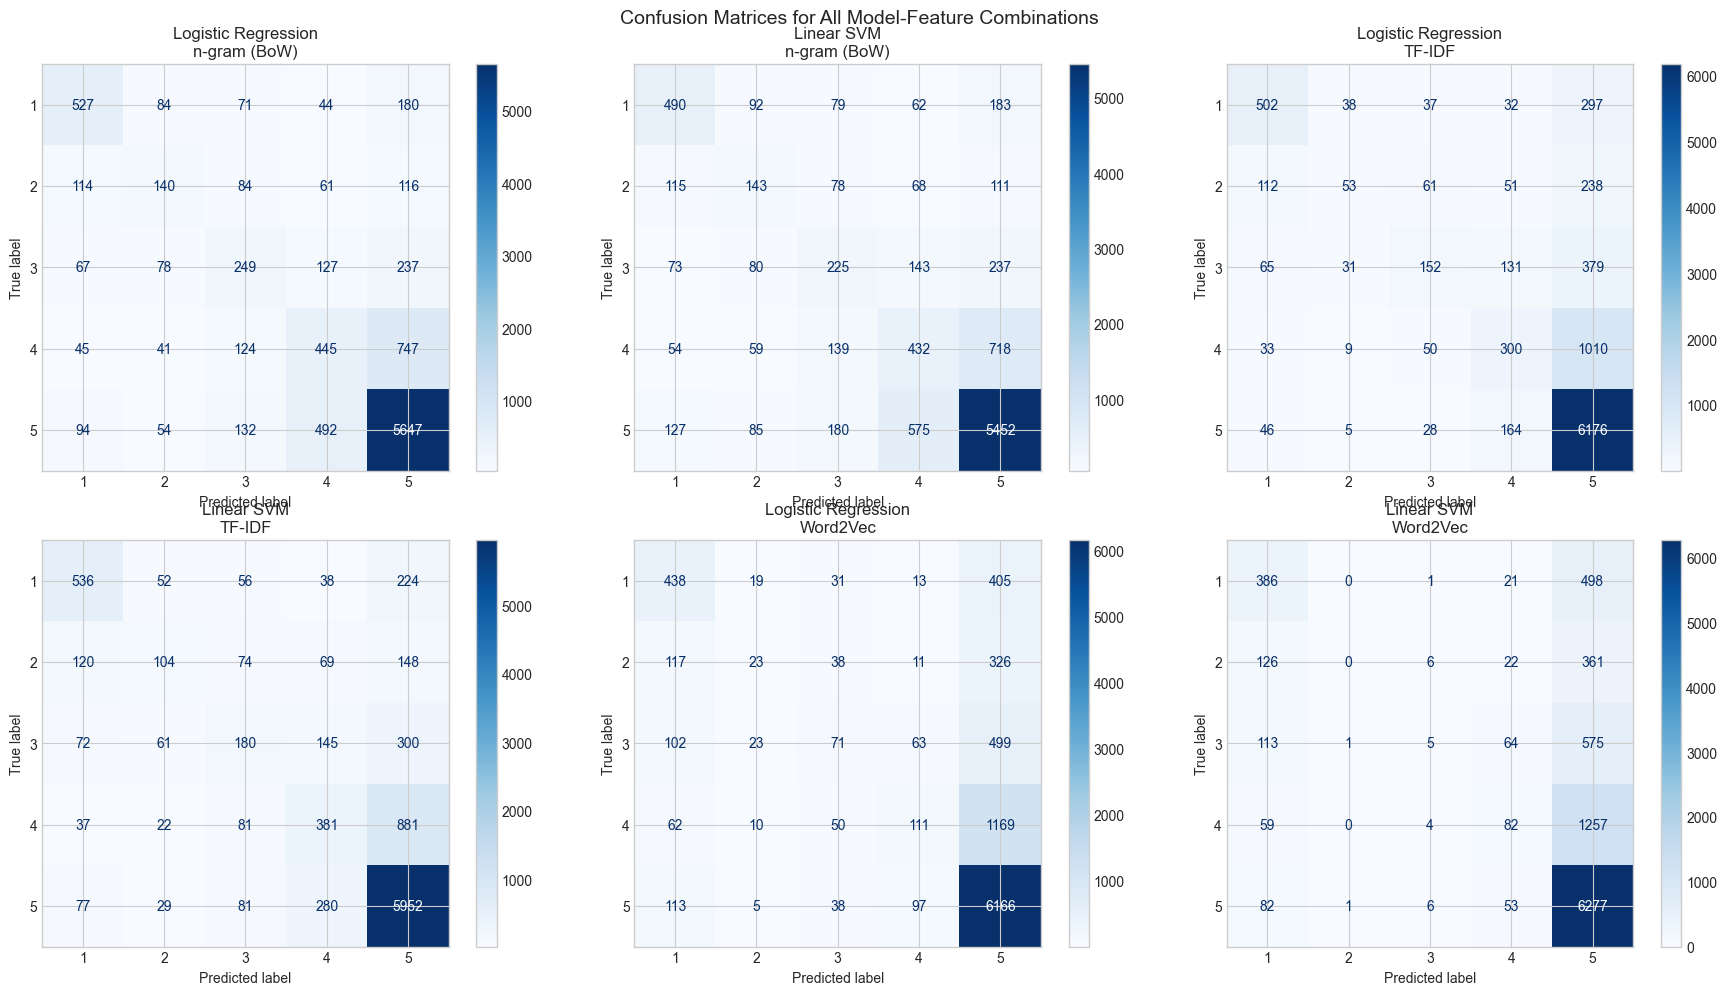

Saved: assignment1_images/confusion_matrices.png

Step 6: Results Summary
+----------------+---------------------+------------+------------+
| Feature Type   | Model               |   Accuracy |   F1-score |
+================+=====================+============+============+
| n-gram (BoW)   | Logistic Regression |     0.7008 |     0.6886 |
+----------------+---------------------+------------+------------+
| n-gram (BoW)   | Linear SVM          |     0.6742 |     0.6675 |
+----------------+---------------------+------------+------------+
| TF-IDF         | Logistic Regression |     0.7183 |     0.6708 |
+----------------+---------------------+------------+------------+
| TF-IDF         | Linear SVM          |     0.7153 |     0.6864 |
+----------------+---------------------+------------+------------+
| Word2Vec       | Logistic Regression |     0.6809 |     0.6072 |
+----------------+---------------------+------------+------------+
| Word2Vec       | Linear SVM          |     0.675  |  

In [194]:
# ============================================================
# 主函数
# Main Function
# ============================================================
def main():
    # ============================================================
    # 步骤 0：实验初始化
    # Step 0: Lab Initialization
    # ============================================================
    student_name, student_number = initialize_lab()

    # ============================================================
    # 步骤 1：数据加载
    # Step 1: Data Loading
    # ============================================================
    df = load_data("Reviews.csv")

    # ============================================================
    # 步骤 2：数据预处理
    # Step 2: Data Preprocessing
    # ============================================================
    df = preprocess_dataset(df)

    # ============================================================
    # 步骤 3A：训练集/测试集划分
    # Step 3A: Train/Test Split
    # ============================================================
    X_train, X_test, y_train, y_test, X_train_tokens, X_test_tokens = split_data(df)

    # ============================================================
    # 步骤 3B：n-gram (BoW) 特征提取
    # Step 3B: n-gram (BoW) Feature Extraction
    # ============================================================
    X_train_bow, X_test_bow, bow_vectorizer = extract_ngram_features(X_train, X_test)

    # ============================================================
    # 步骤 3C：TF-IDF 特征提取
    # Step 3C: TF-IDF Feature Extraction
    # ============================================================
    X_train_tfidf, X_test_tfidf, tfidf_vectorizer = extract_tfidf_features(X_train, X_test)

    # ============================================================
    # 步骤 3D：Word2Vec 特征提取
    # Step 3D: Word2Vec Feature Extraction
    # ============================================================
    X_train_w2v, X_test_w2v, w2v_model = extract_word2vec_features(X_train_tokens, X_test_tokens)

    # 组织所有特征供模型训练使用
    # Organize all features for model training
    features_dict = {
        "n-gram (BoW)": (X_train_bow, X_test_bow),
        "TF-IDF": (X_train_tfidf, X_test_tfidf),
        "Word2Vec": (X_train_w2v, X_test_w2v),
    }

    # ============================================================
    # 步骤 4：训练所有模型并评估
    # Step 4: Train All Models and Evaluate
    # ============================================================
    all_results = run_all_models(features_dict, y_train, y_test)

    # ============================================================
    # 步骤 5：绘制混淆矩阵
    # Step 5: Plot Confusion Matrices
    # ============================================================
    plot_confusion_matrices(all_results)

    # ============================================================
    # 步骤 6：打印结果汇总
    # Step 6: Print Results Summary
    # ============================================================
    best = print_results_summary(all_results)

    # ============================================================
    # 步骤 7：超参数调优（使用 TF-IDF 特征）
    # Step 7: Hyperparameter Tuning (using TF-IDF features)
    # ============================================================
    lr_grid, svm_grid = tune_hyperparameters(X_train_tfidf, y_train, X_test_tfidf, y_test)

    # ============================================================
    # 步骤 8：错误分析（基于预处理后的 tokens）
    # Step 8: Error Analysis (based on preprocessed tokens)
    # ============================================================
    X_test_text = df.loc[X_test.index, "Text"]           # 原文（用于展示和检测丢失信号）
    X_test_tokens_list = df.loc[X_test.index, "tokens"]  # 预处理后的 tokens（模型实际输入）
    categories = error_analysis(all_results, X_test_text, X_test_tokens_list, y_test)


# 程序入口点
# Program entry point
if __name__ == "__main__":
    main()